In [ ]:
from math import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd




# Функция из уравнения: 1.2 - ln(x) - 4sin(2x) = 0
def f(x):
    return 2 * log(x + 7) - 5 * sin(x)

1 задание

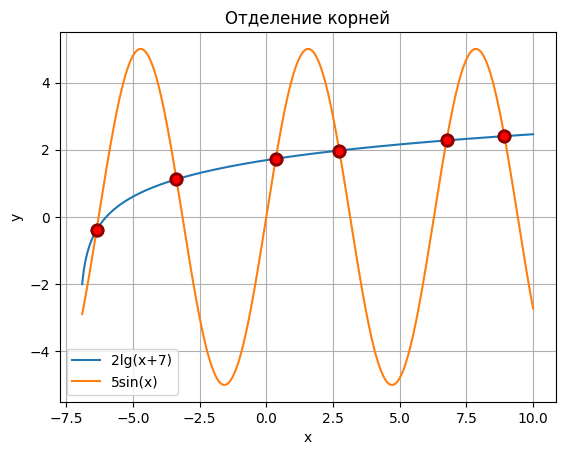

Интервалы, содержащие корни:
Корень на [-6.39; -6.36]
Корень на [-3.38; -3.34]
Корень на [0.35; 0.38]
Корень на [2.72; 2.75]
Корень на [6.75; 6.78]
Корень на [8.92; 8.95]


In [ ]:
x = np.linspace(-6.9, 10, 500)
y1 = 2 * np.log10(x + 7)
y2 = 5 * np.sin(x)


roots = []
for i in range(len(x)-1):
    if (y1[i] - y2[i]) * (y1[i+1] - y2[i+1]) < 0:
        a, b = x[i], x[i+1]
        for _ in range(30):
            c = (a + b) / 2
            if (2 * np.log10(a + 7) - 5 * np.sin(a)) * (2 * np.log10(c + 7) - 5 * np.sin(c)) < 0:
                b = c
            else:
                a = c
        roots.append(c)

plt.plot(x, y1, label='2lg(x+7)')
plt.plot(x, y2, label='5sin(x)')


for root in roots:
    plt.plot(root, 2 * np.log10(root + 7), 'ro', markersize=8, markeredgecolor='darkred', markeredgewidth=2)
    plt.plot(root, 5 * np.sin(root), 'ro', markersize=8, markeredgecolor='darkred', markeredgewidth=2)

plt.grid(True)
plt.legend()
plt.title('Отделение корней')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

print("Интервалы, содержащие корни:")
for i in range(len(x)-1):
    if (y1[i] - y2[i]) * (y1[i+1] - y2[i+1]) < 0:
        print(f"Корень на [{x[i]:.2f}; {x[i+1]:.2f}]")



2 задание

In [17]:
def bisection(a, b, eps=1e-3):
    data = []
    n = 1

    while (b - a) / 2 > eps:
        c = (a + b) / 2

        data.append([n, a, b, c, f(c)])

        if f(a) * f(c) < 0:
            b = c
        else:
            a = c

        n += 1

    return (a + b) / 2, data


a = 0.35
b = 0.36

root, steps = bisection(a, b)


df = pd.DataFrame(steps, columns=["n", "a", "b", "c", "f(c)"])


df = df.round(5)

print("МЕТОД ПОЛОВИННОГО ДЕЛЕНИЯ\n")
print(df)

print("\nОтвет:")
print(f"x ≈ {root:.6f}")

МЕТОД ПОЛОВИННОГО ДЕЛЕНИЯ

   n       a     b        c     f(c)
0  1  0.3500  0.36  0.35500  2.25281
1  2  0.3550  0.36  0.35750  2.24177
2  3  0.3575  0.36  0.35875  2.23626

Ответ:
x ≈ 0.359375


3 задание

In [ ]:

def phi(x):
    return asin((2 * log10(x + 7)) / 5)


def simple_iteration(x0, eps=1e-6):
    data = []
    n = 1
    x = x0

    while True:
        x_new = phi(x)
        diff = abs(x_new - x)

        data.append([n, x, x_new, diff])

        if diff < eps:
            return x_new, data

        x = x_new
        n += 1

x0 = 0.3

root, steps = simple_iteration(x0)

df = pd.DataFrame(steps, columns=["n", "x_n", "x_(n+1)", "|x_(n+1)-x_n|"])


df = df.round(6)

print("МЕТОД ПРОСТОЙ ИТЕРАЦИИ\n")
print(df)

print("\nОтвет:")
print(f"x ≈ {root:.6f}")

МЕТОД ПРОСТОЙ ИТЕРАЦИИ

   n       x_n   x_(n+1)  |x_(n+1)-x_n|
0  1  0.300000  0.352589       0.052589
1  2  0.352589  0.353919       0.001329
2  3  0.353919  0.353952       0.000033
3  4  0.353952  0.353953       0.000001

Ответ:
x ≈ 0.354


4 задание 

ЗАДАНИЕ 4: КОМБИНИРОВАННЫЙ МЕТОД

   n         x     x_new      diff
0  1  0.350000  0.353954  0.003954
1  2  0.353954  0.353953  0.000001

Количество итераций: 2
Корень: x ≈ 0.353953


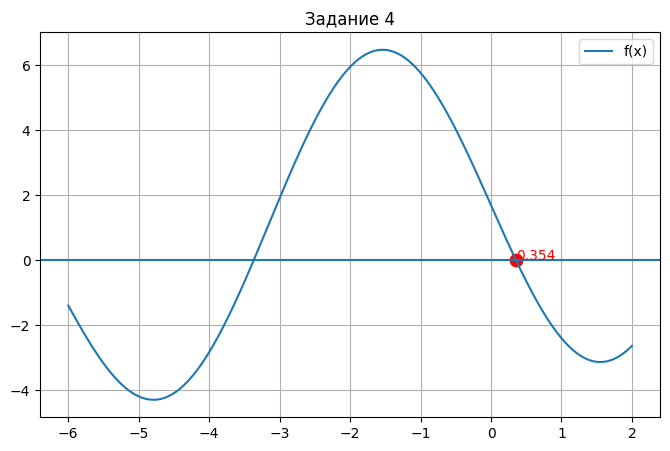

In [ ]:


# функция
def f(x):
    return 2 * log10(x + 7) - 5 * sin(x)

def df(x):
    return 2/((x+7)*log(10)) - 5*cos(x)

# комбинированный метод
def combined(a, b, eps=1e-6):
    data = []
    n = 1
    x = a

    while True:
        x_chord = x - f(x)*(b-x)/(f(b)-f(x))
        x_newton = x - f(x)/df(x)
        x_new = (x_chord + x_newton)/2
        diff = abs(x_new - x)

        data.append([n, x, x_new, diff])

        if diff < eps:
            return x_new, data

        x = x_new
        n += 1

root, steps = combined(0.35, 0.36)

# таблица
df_table = pd.DataFrame(steps, columns=["n", "x", "x_new", "diff"]).round(6)

print("ЗАДАНИЕ 4: КОМБИНИРОВАННЫЙ МЕТОД\n")
print(df_table)
print(f"\nКоличество итераций: {len(steps)}")
print(f"Корень: x ≈ {root:.6f}")

# график
x_vals = np.linspace(-6, 2, 1000)
y_vals = [f(i) for i in x_vals]

plt.figure(figsize=(8,5))
plt.plot(x_vals, y_vals, label='f(x)')
plt.axhline(0)

plt.scatter(root, 0, color='red', s=80)
plt.text(root, 0, f'{root:.3f}', color='red')

plt.grid()
plt.legend()
plt.title("Задание 4")
plt.show()

5 задание 

ЗАДАНИЕ 5

   n         x     x_new      diff
0  1  0.300000  0.353953  0.053953
1  2  0.353953  0.353953  0.000000
2  3  0.353953  0.353953  0.000000
3  4  0.353953  0.353953  0.000000
4  5  0.353953  0.353953  0.000000

Количество итераций: 5
Корень: x ≈ 0.353953


/var/folders/ft/29jcgr2n4v16jl75g72kv92m0000gn/T/ipykernel_74671/1081373234.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 2 * log10(x + 7) - 5 * sin(x)


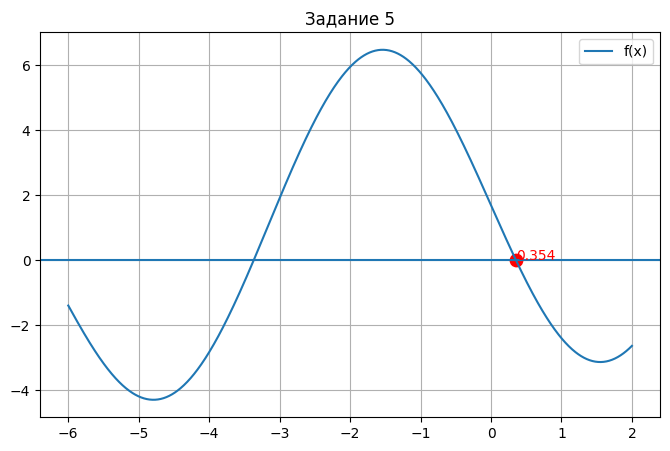

In [27]:
def f(x):
    return 2 * log10(x + 7) - 5 * sin(x)

# "итерации" через последовательные приближения
def iterative_process(x0, steps_count=5):
    data = []
    x = x0

    for n in range(1, steps_count + 1):
        x_new = fsolve(f, x)[0]
        diff = abs(x_new - x)
        data.append([n, x, x_new, diff])
        x = x_new

    return x, data

root, steps = iterative_process(0.3)

df_table = pd.DataFrame(steps, columns=["n", "x", "x_new", "diff"]).round(6)

print("ЗАДАНИЕ 5\n")
print(df_table)
print(f"\nКоличество итераций: {len(steps)}")
print(f"Корень: x ≈ {root:.6f}")


x_vals = np.linspace(-6, 2, 1000)
y_vals = [f(i) for i in x_vals]

plt.figure(figsize=(8,5))
plt.plot(x_vals, y_vals, label='f(x)')
plt.axhline(0)

plt.scatter(root, 0, color='red', s=80)
plt.text(root, 0, f'{root:.3f}', color='red')

plt.grid()
plt.legend()
plt.title("Задание 5")
plt.show()

Метод сошелся за 5 итерации-это очень быстро
